In [1]:
# TP2 – Clustering et détection d’anomalies  
## IFT599 / IFT799 – Science des données


In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

class GapStopping(tf.keras.callbacks.Callback):
    def __init__(self, max_gap=0.05, min_epochs=5):
        super().__init__()
        self.max_gap = max_gap
        self.min_epochs = min_epochs

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        loss = logs.get("loss")
        val_loss = logs.get("val_loss")

        # on attend quelques époques avant de regarder l'écart
        if epoch + 1 >= self.min_epochs and loss is not None and val_loss is not None:
            gap = abs(val_loss - loss)
            if gap <= self.max_gap:
                print(f"\nArrêt: écart train/val {gap:.4f} <= {self.max_gap}")
                self.model.stop_training = True

# Pour que Python trouve le dossier src/
# (le notebook est dans C:\Users\carlo\tp2_ift599_ift799\notebooks)
sys.path.append(os.path.join("..", "src"))

from preprocess import (
    prepare_hiseq_all_spaces,
    normalize_ecg_splits,
)
from models import (
    run_kmeans,
    run_dbscan,
    run_spectral,
    compute_internal_metrics,
    compute_external_metrics,
)
from models_anomaly import (
    run_isolation_forest,
    evaluate_threshold,
    build_autoencoder,
    train_autoencoder,
    build_deep_autoencoder,
)

from sklearn.decomposition import PCA
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve,
    auc,
)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

np.random.seed(42)


In [3]:
## 2. Jeux de données et prétraitement


In [4]:
# Chargement et préparation des données Hi-Seq
feature_spaces, y_hiseq, models_hiseq = prepare_hiseq_all_spaces()

for name, X in feature_spaces.items():
    print(name, X.shape)

print("Taille de y_hiseq :", y_hiseq.shape)


C:\Users\carlo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


full (801, 20531)
pca100 (801, 100)
umap100 (801, 100)
Taille de y_hiseq : (801,)


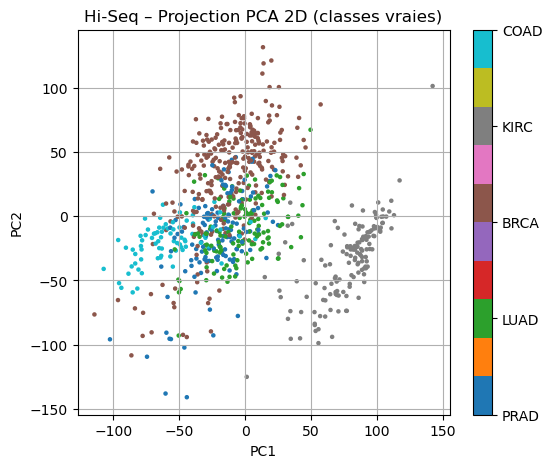

In [5]:
import pandas as pd

X_full = feature_spaces["full"]

# Projection PCA 2D
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_full)

# Encodage des labels string -> entiers 0,1,2,...
y_codes, class_names = pd.factorize(y_hiseq)

plt.figure(figsize=(6, 5))
sc = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_codes, s=5, cmap="tab10")
plt.title("Hi-Seq – Projection PCA 2D (classes vraies)")
plt.xlabel("PC1")
plt.ylabel("PC2")

cbar = plt.colorbar(sc, ticks=range(len(class_names)))
cbar.ax.set_yticklabels(class_names)

plt.show()


In [6]:
### 2.2 Données ECG

In [7]:
(X_train, y_train), (X_val, y_val), (X_test, y_test), ecg_scaler = normalize_ecg_splits()

print("Train :", X_train.shape, " (uniquement normaux)")
print("Val   :", X_val.shape)
print("Test  :", X_test.shape)

print("\nValidation - # anomalies :", (y_val == 1).sum(), "/", len(y_val))
print("Test        - # anomalies :", (y_test == 1).sum(), "/", len(y_test))


Train : (1247, 140)  (uniquement normaux)
Val   : (792, 140)
Test  : (2959, 140)

Validation - # anomalies : 584 / 792
Test        - # anomalies : 2335 / 2959


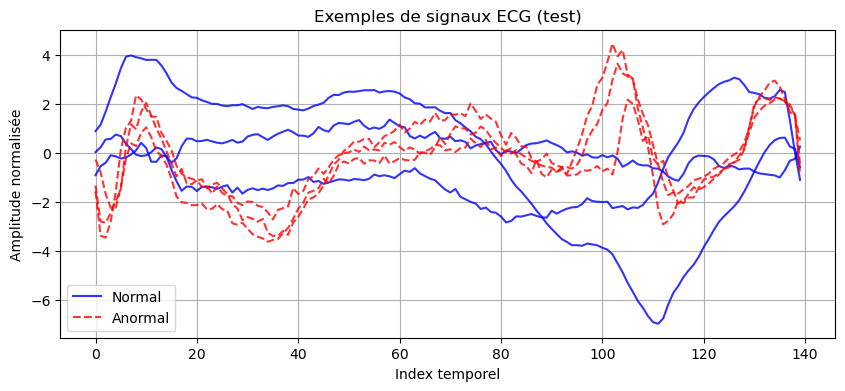

In [8]:
# Exemples de signaux normaux vs anormaux (ensemble de test)
idx_norm = np.where(y_test == 0)[0][:3]
idx_anom = np.where(y_test == 1)[0][:3]

plt.figure(figsize=(10, 4))
for i, idx in enumerate(idx_norm):
    plt.plot(X_test[idx], alpha=0.8, label="Normal" if i == 0 else "", color="blue")

for i, idx in enumerate(idx_anom):
    plt.plot(X_test[idx], alpha=0.8, linestyle="--", label="Anormal" if i == 0 else "", color="red")

plt.title("Exemples de signaux ECG (test)")
plt.xlabel("Index temporel")
plt.ylabel("Amplitude normalisée")
plt.legend()
plt.show()


C:\Users\carlo\AppData\Local\Temp\ipykernel_33996\1982542173.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


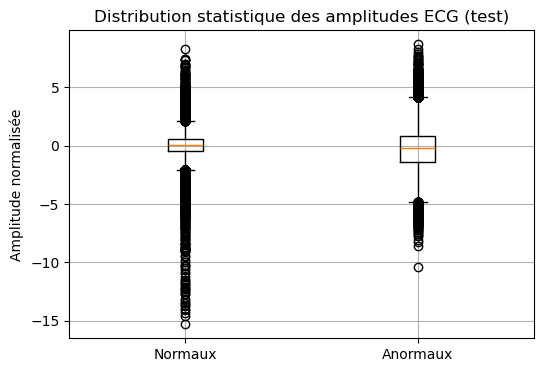

In [9]:
plt.figure(figsize=(6, 4))
plt.boxplot(
    [X_test[y_test == 0].flatten(), X_test[y_test == 1].flatten()],
    labels=["Normaux", "Anormaux"]
)
plt.title("Distribution statistique des amplitudes ECG (test)")
plt.ylabel("Amplitude normalisée")
plt.show()


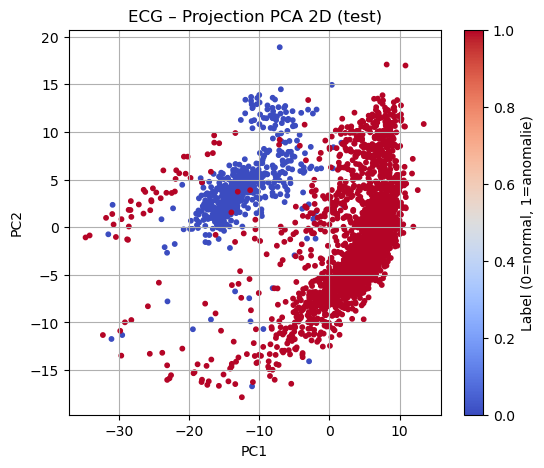

In [10]:
pca_ecg = PCA(n_components=2, random_state=42)
X_ecg_2d = pca_ecg.fit_transform(X_test)

plt.figure(figsize=(6, 5))
sc = plt.scatter(X_ecg_2d[:, 0], X_ecg_2d[:, 1], c=y_test, s=10, cmap="coolwarm")
plt.title("ECG – Projection PCA 2D (test)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(sc, label="Label (0=normal, 1=anomalie)")
plt.show()


In [11]:
## 3. Clustering non supervisé sur Hi-Seq

In [12]:
results_clust = []
seeds = list(range(10))

for space_name, X in feature_spaces.items():
    print(f"\n=== Feature Space: {space_name} ===")
    
    for seed in seeds:
        # K-Means
        labels, t = run_kmeans(X, n_clusters=10, seed=seed)
        metrics_int = compute_internal_metrics(X, labels)
        metrics_ext = compute_external_metrics(y_hiseq, labels)
        results_clust.append({
            "algo": "kmeans",
            "space": space_name,
            "seed": seed,
            "time": t,
            **metrics_int,
            **metrics_ext,
        })

        # DBSCAN
        labels, t = run_dbscan(X, eps=0.5, min_samples=5)
        metrics_int = compute_internal_metrics(X, labels)
        metrics_ext = compute_external_metrics(y_hiseq, labels)
        results_clust.append({
            "algo": "dbscan",
            "space": space_name,
            "seed": seed,
            "time": t,
            **metrics_int,
            **metrics_ext,
        })

        # Spectral Clustering
        labels, t = run_spectral(X, n_clusters=10, seed=seed)
        metrics_int = compute_internal_metrics(X, labels)
        metrics_ext = compute_external_metrics(y_hiseq, labels)
        results_clust.append({
            "algo": "spectral",
            "space": space_name,
            "seed": seed,
            "time": t,
            **metrics_int,
            **metrics_ext,
        })

df_clust = pd.DataFrame(results_clust)
df_clust.head()



=== Feature Space: full ===


C:\Users\carlo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\carlo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\carlo\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\carlo\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^


=== Feature Space: pca100 ===


C:\Users\carlo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\carlo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\carlo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\carlo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window


=== Feature Space: umap100 ===


C:\Users\carlo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\carlo\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
C:\Users\carlo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\carlo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the 

,algo,space,seed,time,silhouette,davies_bouldin,calinski,ARI,homogeneity,completeness,v_measure
0,kmeans,full,0,1.066922,0.073708,3.013408,41.361188,0.536497,0.942539,0.635529,0.759170
1,dbscan,full,0,3.441018,NaN,NaN,NaN,0.000000,0.000000,1.000000,0.000000
2,spectral,full,0,2.991427,0.091055,2.698901,40.811223,0.658547,0.980669,0.699778,0.816748
3,kmeans,full,1,2.244187,0.111192,2.782346,40.292770,0.697740,0.932615,0.687455,0.791485
4,dbscan,full,1,3.847360,NaN,NaN,NaN,0.000000,0.000000,1.000000,0.000000


In [13]:
df_clust_summary = df_clust.groupby(["algo", "space"]).mean(numeric_only=True).round(4)
df_clust_summary


seed    time  silhouette  davies_bouldin    calinski  \
algo     space                                                           
dbscan   full      4.5  3.7118         NaN             NaN         NaN   
         pca100    4.5  0.0375         NaN             NaN         NaN   
         umap100   4.5  0.0415      0.5841          0.4244  16917.0625   
kmeans   full      4.5  2.6093      0.0922          2.8691     40.2270   
         pca100    4.5  0.0529      0.1559          2.2564     68.9670   
         umap100   4.5  0.0509      0.5663          0.8424  22197.1566   
spectral full      4.5  2.9446      0.0911          2.6989     40.8112   
         pca100    4.5  0.5649      0.1487          2.0781     67.9756   
         umap100   4.5  0.4916      0.1743          1.2067   4756.4168   

                     ARI  homogeneity  completeness  v_measure  
algo     space                                                  
dbscan   full     0.0000       0.0000        1.0000     0.0000  
         pca100   0.0000       0.0000        1.0000     0.0000  
         umap100  0.9900       0.9901        0.9859     0.9880  
kmeans   full     0.6258       0.9433        0.6723     0.7848  
         pca100   0.6161       0.9427        0.6658     0.7802  
         umap100  0.5763       0.9920        0.6741     0.8027  
spectral full     0.6585       0.9807        0.6998     0.8167  
         pca100   0.6650       0.9753        0.6984     0.8140  
         umap100  0.4746       0.8422        0.6229     0.7158

C:\Users\carlo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


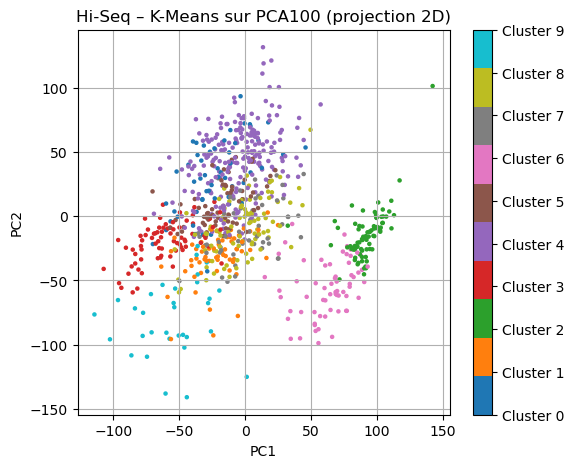

In [14]:
from sklearn.cluster import KMeans

# K-Means sur PCA100
kmeans = KMeans(n_clusters=10, random_state=0, n_init="auto")
labels_km = kmeans.fit_predict(feature_spaces["pca100"])

# Projection PCA2D pour affichage
X_2d_pca = PCA(n_components=2, random_state=42).fit_transform(feature_spaces["pca100"])

plt.figure(figsize=(6, 5))
sc = plt.scatter(X_2d_pca[:, 0], X_2d_pca[:, 1], c=labels_km, s=5, cmap="tab10")
plt.title("Hi-Seq – K-Means sur PCA100 (projection 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
cbar = plt.colorbar(sc, ticks=range(10))
cbar.ax.set_yticklabels([f"Cluster {i}" for i in range(10)])
plt.show()


In [15]:
## 4. Détection d’anomalies sur ECG

In [16]:
# Entraînement IF sur train et scores sur validation
(val_scores, t_if_val) = run_isolation_forest(X_train, X_val)

# Seuil : percentile bas des scores des normaux en validation
percentile = 5
threshold_if = np.percentile(val_scores[y_val == 0], percentile)
threshold_if


np.float64(-0.5546731289829203)

In [17]:
# Scores sur test + métriques IF
(test_scores, t_if_test) = run_isolation_forest(X_train, X_test)
metrics_if = evaluate_threshold(test_scores, threshold_if, y_test)
metrics_if


{'AUC': np.float64(0.9462032614066875),
 'F1': 0.22104866088268577,
 'precision': 0.9272151898734177,
 'recall': 0.12548179871520343,
 'confusion': array([[ 601,   23],
        [2042,  293]])}

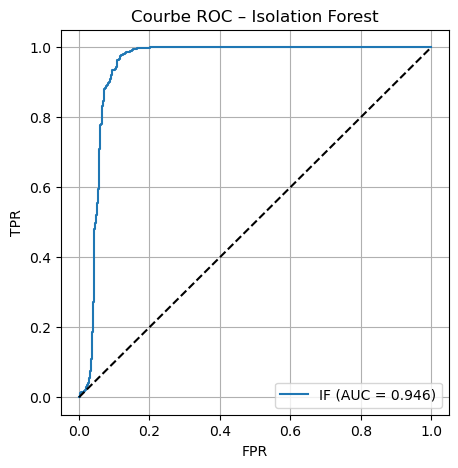

In [18]:
# Courbe ROC IF
fpr_if, tpr_if, _ = roc_curve(y_test, -test_scores)
auc_if = auc(fpr_if, tpr_if)

plt.figure(figsize=(5, 5))
plt.plot(fpr_if, tpr_if, label=f"IF (AUC = {auc_if:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Courbe ROC – Isolation Forest")
plt.legend()
plt.grid(True)
plt.show()


In [19]:
from tensorflow.keras.callbacks import EarlyStopping

input_dim = X_train.shape[1]
ae = build_autoencoder(input_dim)

# ❗ On ne garde que les normaux de la validation pour l'entraînement / early stopping
X_val_norm = X_val[y_val == 0]

es = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

history_ae, t_ae_train = train_autoencoder(
    ae,
    X_train,
    X_val_norm,      # <-- ici : seulement les normaux
    epochs=30,
    batch_size=64,
    callbacks=[es],
)



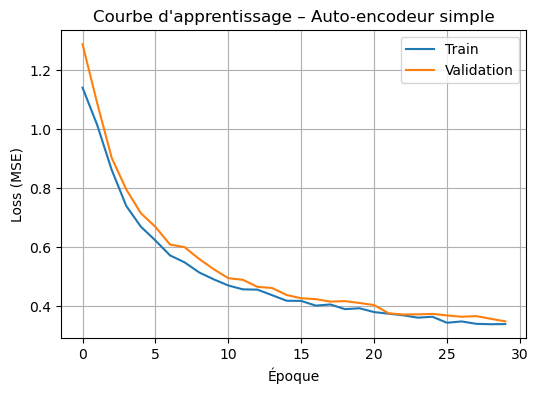

In [20]:
# Courbe d'apprentissage AE simple
plt.figure(figsize=(6, 4))
plt.plot(history_ae.history["loss"], label="Train")
plt.plot(history_ae.history["val_loss"], label="Validation")
plt.xlabel("Époque")
plt.ylabel("Loss (MSE)")
plt.title("Courbe d'apprentissage – Auto-encodeur simple")
plt.legend()
plt.grid(True)
plt.show()


In [21]:
# Erreurs sur validation + seuil
#val_recon = np.mean((ae.predict(X_val) - X_val)**2, axis=1)

#threshold_ae = np.percentile(val_recon[y_val == 0], 95)
#threshold_ae
from sklearn.metrics import f1_score

# Erreurs de reconstruction sur toute la validation (normaux + anomalies)
val_recon_full = np.mean((ae.predict(X_val) - X_val)**2, axis=1)

# On balaye plusieurs seuils possibles (quantiles de la distribution)
quantiles = np.linspace(0.80, 0.995, 50)   # à ajuster si tu veux
candidate_thresholds = np.quantile(val_recon_full, quantiles)

best_f1 = -1
best_threshold = None

for t in candidate_thresholds:
    y_pred_val = (val_recon_full > t).astype(int)  # 1 = anomalie
    f1 = f1_score(y_val, y_pred_val)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

best_threshold, best_f1
threshold_ae = best_threshold


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  


In [22]:
# Erreurs sur test + métriques AE simple
test_recon = np.mean((ae.predict(X_test) - X_test)**2, axis=1)
y_pred_ae = (test_recon > threshold_ae).astype(int)

auc_ae = roc_auc_score(y_test, test_recon)
f1_ae = f1_score(y_test, y_pred_ae)
prec_ae = precision_score(y_test, y_pred_ae)
rec_ae = recall_score(y_test, y_pred_ae)
cm_ae = confusion_matrix(y_test, y_pred_ae)

auc_ae, f1_ae, prec_ae, rec_ae, cm_ae


93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


(np.float64(0.9552915499917642),
 0.36414176511466295,
 0.9650092081031307,
 0.22441113490364026,
 array([[ 605,   19],
        [1811,  524]]))

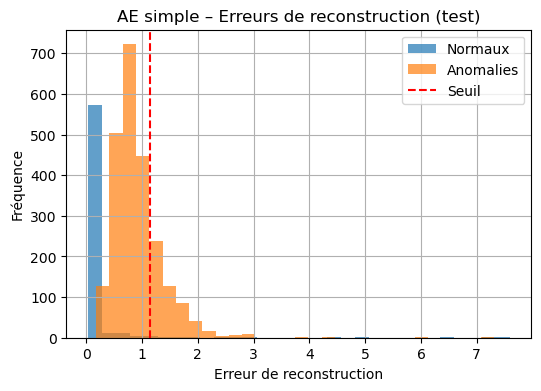

In [23]:
# Distribution des erreurs AE simple
err_norm = test_recon[y_test == 0]
err_anom = test_recon[y_test == 1]

plt.figure(figsize=(6, 4))
plt.hist(err_norm, bins=30, alpha=0.7, label="Normaux")
plt.hist(err_anom, bins=30, alpha=0.7, label="Anomalies")
plt.axvline(threshold_ae, color="red", linestyle="--", label="Seuil")
plt.xlabel("Erreur de reconstruction")
plt.ylabel("Fréquence")
plt.title("AE simple – Erreurs de reconstruction (test)")
plt.legend()
plt.grid(True)
plt.show()


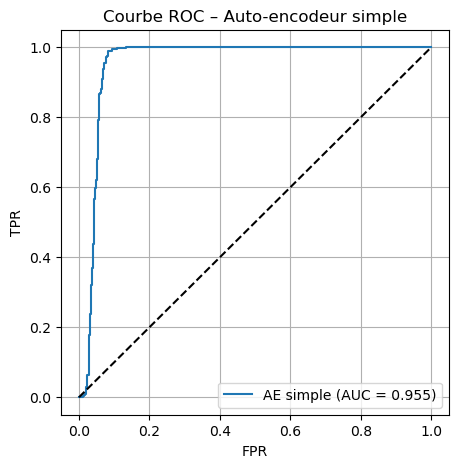

In [24]:
# Courbe ROC AE simple
fpr_ae, tpr_ae, _ = roc_curve(y_test, test_recon)
auc_ae_curve = auc(fpr_ae, tpr_ae)

plt.figure(figsize=(5, 5))
plt.plot(fpr_ae, tpr_ae, label=f"AE simple (AUC = {auc_ae_curve:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Courbe ROC – Auto-encodeur simple")
plt.legend()
plt.grid(True)
plt.show()


In [25]:
from tensorflow.keras.callbacks import EarlyStopping

input_dim = X_train.shape[1]
ae_deep = build_deep_autoencoder(input_dim)

X_val_norm = X_val[y_val == 0]

es_deep = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

history_deep, t_deep_train = train_autoencoder(
    ae_deep,
    X_train,
    X_val_norm,
    epochs=20,        # on limite à 20
    batch_size=64,
    callbacks=[es_deep],
)


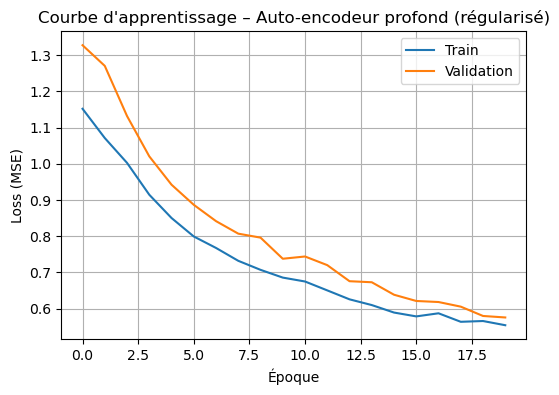

In [26]:
plt.figure(figsize=(6, 4))
plt.plot(history_deep.history["loss"], label="Train")
plt.plot(history_deep.history["val_loss"], label="Validation")
plt.xlabel("Époque")
plt.ylabel("Loss (MSE)")
plt.title("Courbe d'apprentissage – Auto-encodeur profond (régularisé)")
plt.legend()
plt.grid(True)
plt.show()


In [27]:
from sklearn.metrics import f1_score

# Erreurs de reconstruction sur TOUTE la validation (normaux + anomalies)
val_recon_deep_full = np.mean((ae_deep.predict(X_val) - X_val)**2, axis=1)

quantiles = np.linspace(0.80, 0.995, 50)
candidate_thresholds_deep = np.quantile(val_recon_deep_full, quantiles)

best_f1_deep = -1
best_threshold_deep = None

for t in candidate_thresholds_deep:
    y_pred_val_deep = (val_recon_deep_full > t).astype(int)  # 1 = anomalie
    f1 = f1_score(y_val, y_pred_val_deep)
    if f1 > best_f1_deep:
        best_f1_deep = f1
        best_threshold_deep = t

best_threshold_deep, best_f1_deep
threshold_deep = best_threshold_deep



25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  


In [28]:
test_recon_deep = np.mean((ae_deep.predict(X_test) - X_test)**2, axis=1)
y_pred_deep = (test_recon_deep > threshold_deep).astype(int)

auc_deep  = roc_auc_score(y_test, test_recon_deep)
f1_deep   = f1_score(y_test, y_pred_deep)
prec_deep = precision_score(y_test, y_pred_deep)
rec_deep  = recall_score(y_test, y_pred_deep)
cm_deep   = confusion_matrix(y_test, y_pred_deep)

auc_deep, f1_deep, prec_deep, rec_deep, cm_deep


93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


(np.float64(0.9531639488277605),
 0.38837606837606836,
 0.9627118644067797,
 0.24325481798715204,
 array([[ 602,   22],
        [1767,  568]]))

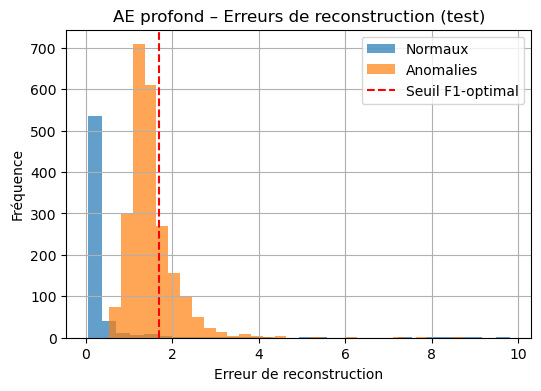

In [29]:
err_norm_deep = test_recon_deep[y_test == 0]
err_anom_deep = test_recon_deep[y_test == 1]

plt.figure(figsize=(6, 4))
plt.hist(err_norm_deep, bins=30, alpha=0.7, label="Normaux")
plt.hist(err_anom_deep, bins=30, alpha=0.7, label="Anomalies")
plt.axvline(threshold_deep, color="red", linestyle="--", label="Seuil F1-optimal")
plt.xlabel("Erreur de reconstruction")
plt.ylabel("Fréquence")
plt.title("AE profond – Erreurs de reconstruction (test)")
plt.legend()
plt.grid(True)
plt.show()


In [30]:
results_anom = [
    ["Isolation Forest",
     metrics_if["AUC"], metrics_if["F1"],
     metrics_if["precision"], metrics_if["recall"],
     metrics_if["confusion"]],
    ["AE simple",
     auc_ae, f1_ae, prec_ae, rec_ae, cm_ae],
    ["AE profond",
     auc_deep, f1_deep, prec_deep, rec_deep, cm_deep],
]

df_anom = pd.DataFrame(
    results_anom,
    columns=["Modèle", "AUC", "F1", "Précision", "Rappel", "Confusion"],
)
df_anom


,Modèle,AUC,F1,Précision,Rappel,Confusion
0,Isolation Forest,0.946203,0.221049,0.927215,0.125482,"[[601, 23], [2042, 293]]"
1,AE simple,0.955292,0.364142,0.965009,0.224411,"[[605, 19], [1811, 524]]"
2,AE profond,0.953164,0.388376,0.962712,0.243255,"[[602, 22], [1767, 568]]"
